In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Data Read
# =========================================================
# 1) PATHS
# =========================================================
data_path = Path("../data/processed/yrbs_recoded.csv")
figures_dir = Path("../outputs/figures")
tables_dir = Path("../outputs/tables")

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2) LOAD DATA
# =========================================================
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully.
Shape: (14041, 114)
   RaceEth  HowOldAreYou  WhatIsYourSex  InWhatGradeAreYou  \
0      7.0           4.0            2.0                2.0   
1      5.0           7.0            2.0                2.0   
2      NaN           NaN            2.0                NaN   
3      7.0           1.0            1.0                1.0   
4      7.0           1.0            1.0                5.0   

   AreYouHispanicOrLatino WhatIsYourRace  HowTallAreYouWithoutShoesInMeters  \
0                     1.0              C                                NaN   
1                     2.0              E                               1.70   
2                     NaN            NaN                                NaN   
3                     1.0              A                               1.63   
4                     1.0              B                                NaN   

   HowMuchDoYouWeighWithoutShoesInKG  BicyleHelmetUse  SeatBeltUse  ...  \
0                           

# Part 1. EDA for Behavior Variable
## Variable: CurrentCigaretteUse
### Behavior Variable Research Question:
### Is the proportion of students who currently use cigarettes different from 0.20?

##### Variable Name: CurrentCigaretteUse
##### Recoded Variable: CurrentCigaretteUse_binary
##### Meaning: Current cigarette use behavior
##### Success = codes 2–7 (currently uses cigarettes)
##### Failure = code 1 (does not currently use cigarettes)
##### Binary coding: 1 = success, 0 = failure

In [3]:
#Create CurrentCiggarettUse frequency table
original_freq = df["CurrentCigaretteUse"].value_counts(dropna=False).sort_index()
original_freq_table = original_freq.reset_index()
original_freq_table.columns = ["Code", "Frequency"]

print("=== Original Code Frequency Table ===")
print(original_freq_table)

=== Original Code Frequency Table ===
   Code  Frequency
0   1.0      10734
1   2.0        753
2   3.0        375
3   4.0        250
4   5.0        295
5   6.0        229
6   7.0        687
7   NaN        718


## Observation↑↑
### This table shows how students were distributed across the original CurrentCigaretteUse response categories.

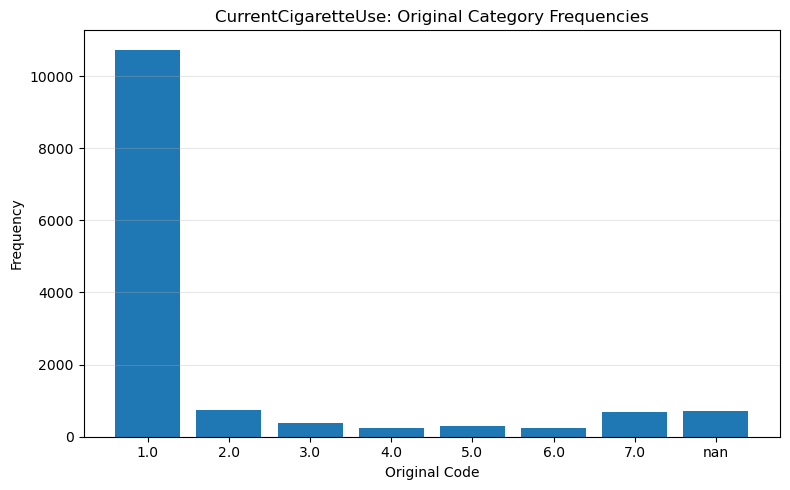

In [4]:
#barplot for CurrentCiggarettUse frequency table
plt.figure(figsize=(8,5))
plt.bar(original_freq_table["Code"].astype(str), original_freq_table["Frequency"])
plt.title("CurrentCigaretteUse: Original Category Frequencies")
plt.xlabel("Original Code")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Observation↑↑
### This bar chart helps visualize which original response categories are most common.

In [5]:
# turn CurrentCigaretteUse into true/false binary form
binary_freq = df["CurrentCigaretteUse_binary"].value_counts(dropna=False).sort_index()
binary_freq_table = binary_freq.reset_index()
binary_freq_table.columns = ["Binary Code", "Frequency"]

print("=== Binary Recoded Frequency Table ===")
print(binary_freq_table)

=== Binary Recoded Frequency Table ===
   Binary Code  Frequency
0          0.0      10734
1          1.0       2589
2          NaN        718


## Observation↑↑
### This table shows the number of students classified as current cigarette users (1) and non-users (0).

In [6]:
#Delete NAN row, covert 1/0 to success/failure
binary_clean = df["CurrentCigaretteUse_binary"].dropna()

success_count = (binary_clean == 1).sum()
failure_count = (binary_clean == 0).sum()
n_behavior = len(binary_clean)

success_prop = success_count / n_behavior
failure_prop = failure_count / n_behavior

behavior_summary = pd.DataFrame({
    "Category": ["Success (Current User)", "Failure (Not Current User)"],
    "Count": [success_count, failure_count],
    "Proportion": [success_prop, failure_prop]
})

print("=== Success / Failure Summary ===")
print(behavior_summary)

=== Success / Failure Summary ===
                     Category  Count  Proportion
0      Success (Current User)   2589    0.194326
1  Failure (Not Current User)  10734    0.805674


## Observation↑↑
### This summary gives the sample count and proportion for students who currently use cigarettes and those who do not.

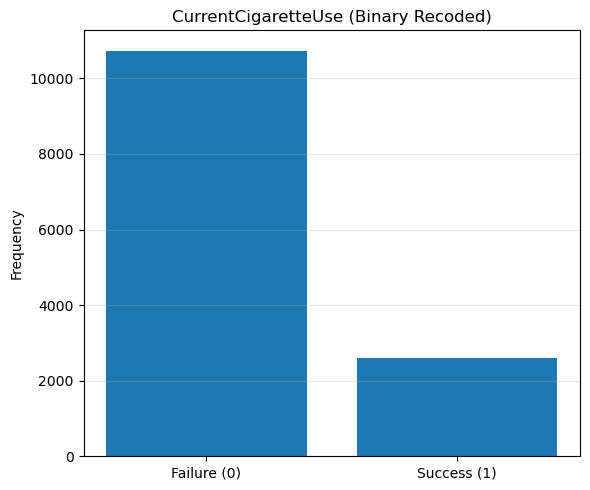

In [7]:
#barplot for CurrentCigaretteUse_binary with png output
plt.figure(figsize=(6,5))
plt.bar(["Failure (0)", "Success (1)"], [failure_count, success_count])
plt.title("CurrentCigaretteUse (Binary Recoded)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "current_cigarette_binary_bar.png", dpi=300)
plt.show()

## Observation↑↑
### This binary bar chart clearly shows whether current cigarette use is common or uncommon in the sample.

In [8]:
#Count the missing data in CurrentCigaretteUse and CurrentCIgaretteUse
missing_behavior_original = df["CurrentCigaretteUse"].isna().sum()
missing_behavior_binary = df["CurrentCigaretteUse_binary"].isna().sum()

behavior_missing_table = pd.DataFrame({
    "Variable": ["CurrentCigaretteUse", "CurrentCigaretteUse_binary"],
    "Missing/Invalid Count": [missing_behavior_original, missing_behavior_binary]
})

print("=== Missing / Invalid Value Count ===")
print(behavior_missing_table)

=== Missing / Invalid Value Count ===
                     Variable  Missing/Invalid Count
0         CurrentCigaretteUse                    718
1  CurrentCigaretteUse_binary                    718


## Observation↑↑
### This table shows how many responses were missing or excluded from the behavior analysis.

# PART 2: EDA for Continuous Variable
## Variable: BMIPCT
### Behavior Variable Research Question:
#### Is the proportion of students who currently use cigarettes different from 0.20?

##### Variable Name: BMIPCT
##### Meaning: Body Mass Index Percentile
##### Valid values used: 0 to 100
##### Missing or invalid values are excluded from the analysis.

In [9]:
#find the useable BMIPCT data
bmi = pd.to_numeric(df["BMIPCT"], errors="coerce")
bmi = bmi.dropna()
bmi = bmi[(bmi >= 0) & (bmi <= 100)]

n_bmi = len(bmi)

print("Final usable BMIPCT sample size:", n_bmi)

Final usable BMIPCT sample size: 13062


In [10]:
#Calculate and define statistic in BMIPCT
mean_bmi = bmi.mean()
median_bmi = bmi.median()
std_bmi = bmi.std(ddof=1)
min_bmi = bmi.min()
q1_bmi = bmi.quantile(0.25) 
q3_bmi = bmi.quantile(0.75)
max_bmi = bmi.max()

bmi_summary = pd.DataFrame({
    "Statistic": ["Sample Size", "Mean", "Median", "Standard Deviation", "Minimum", "Q1", "Q3", "Maximum"],
    "Value": [n_bmi, mean_bmi, median_bmi, std_bmi, min_bmi, q1_bmi, q3_bmi, max_bmi]
})

print("=== BMIPCT Summary Statistics ===")
print(bmi_summary)

=== BMIPCT Summary Statistics ===
            Statistic         Value
0         Sample Size  1.306200e+04
1                Mean  6.482068e+01
2              Median  7.013853e+01
3  Standard Deviation  2.751676e+01
4             Minimum  3.720000e-09
5                  Q1  4.516627e+01
6                  Q3  8.945097e+01
7             Maximum  9.993921e+01


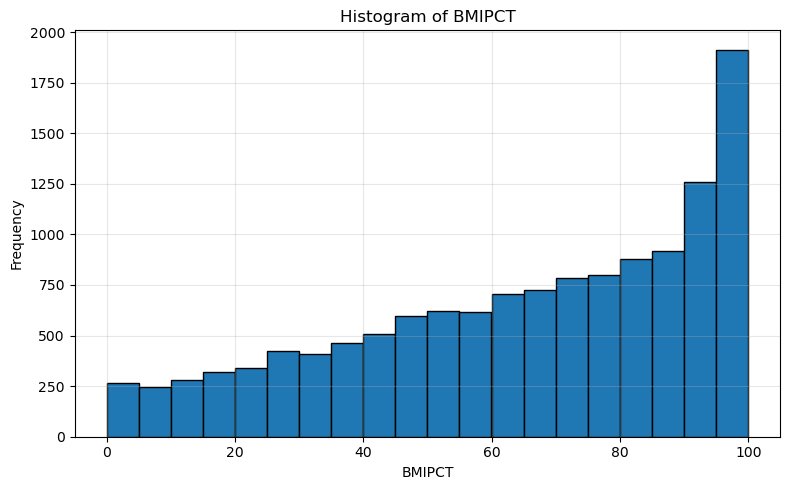

In [11]:
#barplot for BMIPCT while outputing the png
plt.figure(figsize=(8,5))
plt.hist(bmi, bins=20, edgecolor='black')
plt.title("Histogram of BMIPCT")
plt.xlabel("BMIPCT")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "bmipct_histogram.png", dpi=300)
plt.show()

## Observation↑↑
### The histogram shows the shape of the BMIPCT distribution and whether it appears symmetric or skewed.

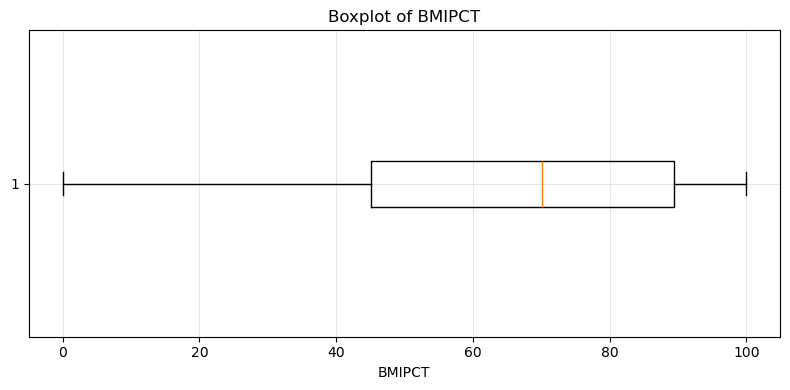

In [12]:
#Boxplot for BMIPCT 
plt.figure(figsize=(8,4))
plt.boxplot(bmi, vert=False)
plt.title("Boxplot of BMIPCT")
plt.xlabel("BMIPCT")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observation↑↑
### The boxplot helps identify spread, median position, and possible outliers in BMIPCT.

In [13]:
#Count the missing data 
missing_bmi = df["BMIPCT"].isna().sum()

bmi_missing_table = pd.DataFrame({
    "Variable": ["BMIPCT"],
    "Missing/Invalid Count": [missing_bmi]
})

print("=== Missing / Invalid Value Count ===")
print(bmi_missing_table)


=== Missing / Invalid Value Count ===
  Variable  Missing/Invalid Count
0   BMIPCT                    979


## Observation↑↑
### This table shows how many BMIPCT values were missing or invalid and therefore excluded.

In [14]:
#IQR analysis
IQR = q3_bmi - q1_bmi
lower_bound = q1_bmi - 1.5 * IQR
upper_bound = q3_bmi + 1.5 * IQR

outliers = bmi[(bmi < lower_bound) | (bmi > upper_bound)]

outlier_table = pd.DataFrame({
    "Statistic": ["IQR", "Lower Bound", "Upper Bound", "Number of Possible Outliers"],
    "Value": [IQR, lower_bound, upper_bound, len(outliers)]
})

print("=== Outlier Check (IQR Method) ===")
print(outlier_table)

=== Outlier Check (IQR Method) ===
                     Statistic       Value
0                          IQR   44.284698
1                  Lower Bound  -21.260777
2                  Upper Bound  155.878015
3  Number of Possible Outliers    0.000000


## Observation↑↑
### The IQR method identifies unusually low or high BMIPCT values that may influence the analysis.
### Since there's no possible outlier, there will be no outlier disortion.

# Part 3: Additional EDA Exploration
## Method: Quartile

In [15]:
#Split the variable into 4 quartile then output
bmi_quartile_groups = pd.qcut(bmi, q=4, duplicates='drop')

quartile_counts = bmi_quartile_groups.value_counts().sort_index().reset_index()
quartile_counts.columns = ["BMIPCT Quartile Range", "Count"]

print("=== BMIPCT Quartile Groups ===")
print(quartile_counts)

=== BMIPCT Quartile Groups ===
      BMIPCT Quartile Range  Count
0  (-0.00099999628, 45.166]   3270
1          (45.166, 70.139]   3261
2          (70.139, 89.451]   3265
3          (89.451, 99.939]   3266


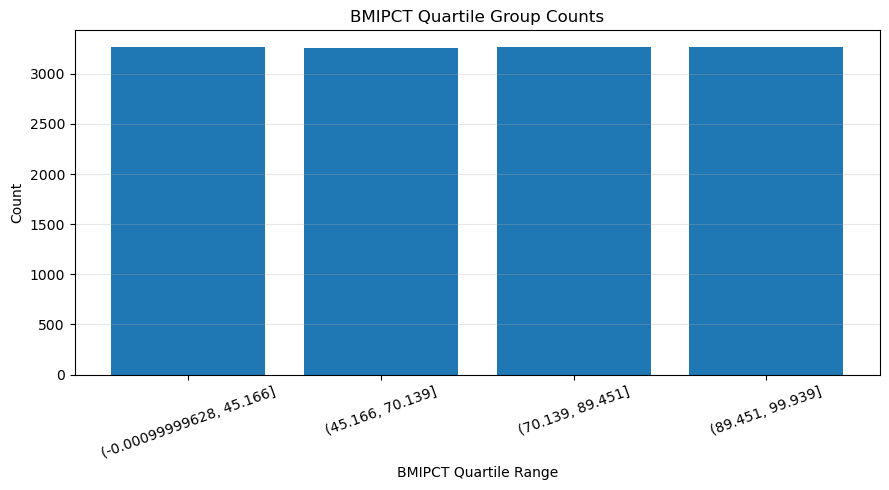

In [16]:
#barplot for the Quartile Group Counts
plt.figure(figsize=(9,5))
plt.bar(quartile_counts["BMIPCT Quartile Range"].astype(str), quartile_counts["Count"])
plt.title("BMIPCT Quartile Group Counts")
plt.xlabel("BMIPCT Quartile Range")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Observation↑↑
### The BMI variable was divided into four equally sized quartiles. Each quartile contains a similar number of observations, ensuring balanced group comparisons. The varying widths of the BMI ranges indicate that the data is not evenly distributed, with some intervals showing greater concentration of values. These quartile groups provide a useful basis for comparing patterns across different BMI levels.

In [17]:
print("=== EDA SUMMARY ===")

print("\nBehavior Variable: CurrentCigaretteUse")
print(f"- Final usable sample size: {n_behavior}")
print(f"- Current cigarette use proportion: {success_prop:.4f}")
print(f"- Non-current cigarette use proportion: {failure_prop:.4f}")

print("\nContinuous Variable: BMIPCT")
print(f"- Final usable sample size: {n_bmi}")
print(f"- Mean BMIPCT: {mean_bmi:.2f}")
print(f"- Median BMIPCT: {median_bmi:.2f}")
print(f"- Standard deviation: {std_bmi:.2f}")
print(f"- Possible outliers: {len(outliers)}")

=== EDA SUMMARY ===

Behavior Variable: CurrentCigaretteUse
- Final usable sample size: 13323
- Current cigarette use proportion: 0.1943
- Non-current cigarette use proportion: 0.8057

Continuous Variable: BMIPCT
- Final usable sample size: 13062
- Mean BMIPCT: 64.82
- Median BMIPCT: 70.14
- Standard deviation: 27.52
- Possible outliers: 0


In [18]:
# =========================================================
# PART 4: SAVE EDA SUMMARY TABLE
# =========================================================

eda_summary_table = pd.DataFrame({
    "Analysis Type": ["Behavior", "Continuous"],
    "Variable": ["CurrentCigaretteUse", "BMIPCT"],
    "Usable Sample Size": [n_behavior, n_bmi],
    "Main Estimate": [success_prop, mean_bmi],
    "Secondary Estimate": [failure_prop, median_bmi],
    "Spread / SD": [np.nan, std_bmi],
    "Minimum": [np.nan, min_bmi],
    "Q1": [np.nan, q1_bmi],
    "Q3": [np.nan, q3_bmi],
    "Maximum": [np.nan, max_bmi],
    "Missing / Invalid Count": [missing_behavior_binary, missing_bmi]
})

print("=== EDA SUMMARY TABLE ===")
print(eda_summary_table)

# Save CSV
eda_summary_table.to_csv(tables_dir / "eda_summary_table.csv", index=False)

print("\nSaved: outputs/tables/eda_summary_table.csv")

=== EDA SUMMARY TABLE ===
  Analysis Type             Variable  Usable Sample Size  Main Estimate  \
0      Behavior  CurrentCigaretteUse               13323       0.194326   
1    Continuous               BMIPCT               13062      64.820683   

   Secondary Estimate  Spread / SD       Minimum        Q1         Q3  \
0            0.805674          NaN           NaN       NaN        NaN   
1           70.138535    27.516756  3.720000e-09  45.16627  89.450968   

     Maximum  Missing / Invalid Count  
0        NaN                      718  
1  99.939213                      979  

Saved: outputs/tables/eda_summary_table.csv
